In [1]:

import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import minimize
from iminuit.cost import LeastSquares

from iminuit import Minuit

sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks")


## asked chat to make a polar inspirede colormap
pallete = [
    "#234F5C",  # deep fjord teal (dark)
    "#F2A47D",  # arctic sunset orange
    "#9975B1",  # low sun gold
    "#98FDEE",  # electric ice cyan
        "#8DF596",  # frozen horizon red

    "#1F7A8C",  # glacial lagoon
    "#FF4E88",  # polar pink sky
    "#2E294E",  # polar night indigo
    "#541388",  # aurora violet
    "#3A5A40",  # tundra moss
    "#A1E3F9",  # fractured ice blue
    "#8E44AD",  # deep aurora magenta
    "#00B3A4",  # icy turquoise
]

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", pallete)

plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.facecolor'] =     "#DDDCDC"  # frozen mist (very light)
## color of legend frame
plt.rcParams["legend.facecolor"] = "#FFFFFF"
plt.rcParams["legend.edgecolor"] = "#010003"
plt.rcParams["legend.framealpha"] = .9

rc = {"font.family" : "serif", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
mpl_markers = ['o', 'v', 's', 'p', '*', 'P', 'd']

(array([2824., 1917., 1609., 1593., 1639., 1787., 1970., 2189., 2325.,
        2147.]),
 array([-1.0000e+00, -8.0001e-01, -6.0002e-01, -4.0003e-01, -2.0004e-01,
        -5.0000e-05,  1.9994e-01,  3.9993e-01,  5.9992e-01,  7.9991e-01,
         9.9990e-01]),
 <BarContainer object of 10 artists>)

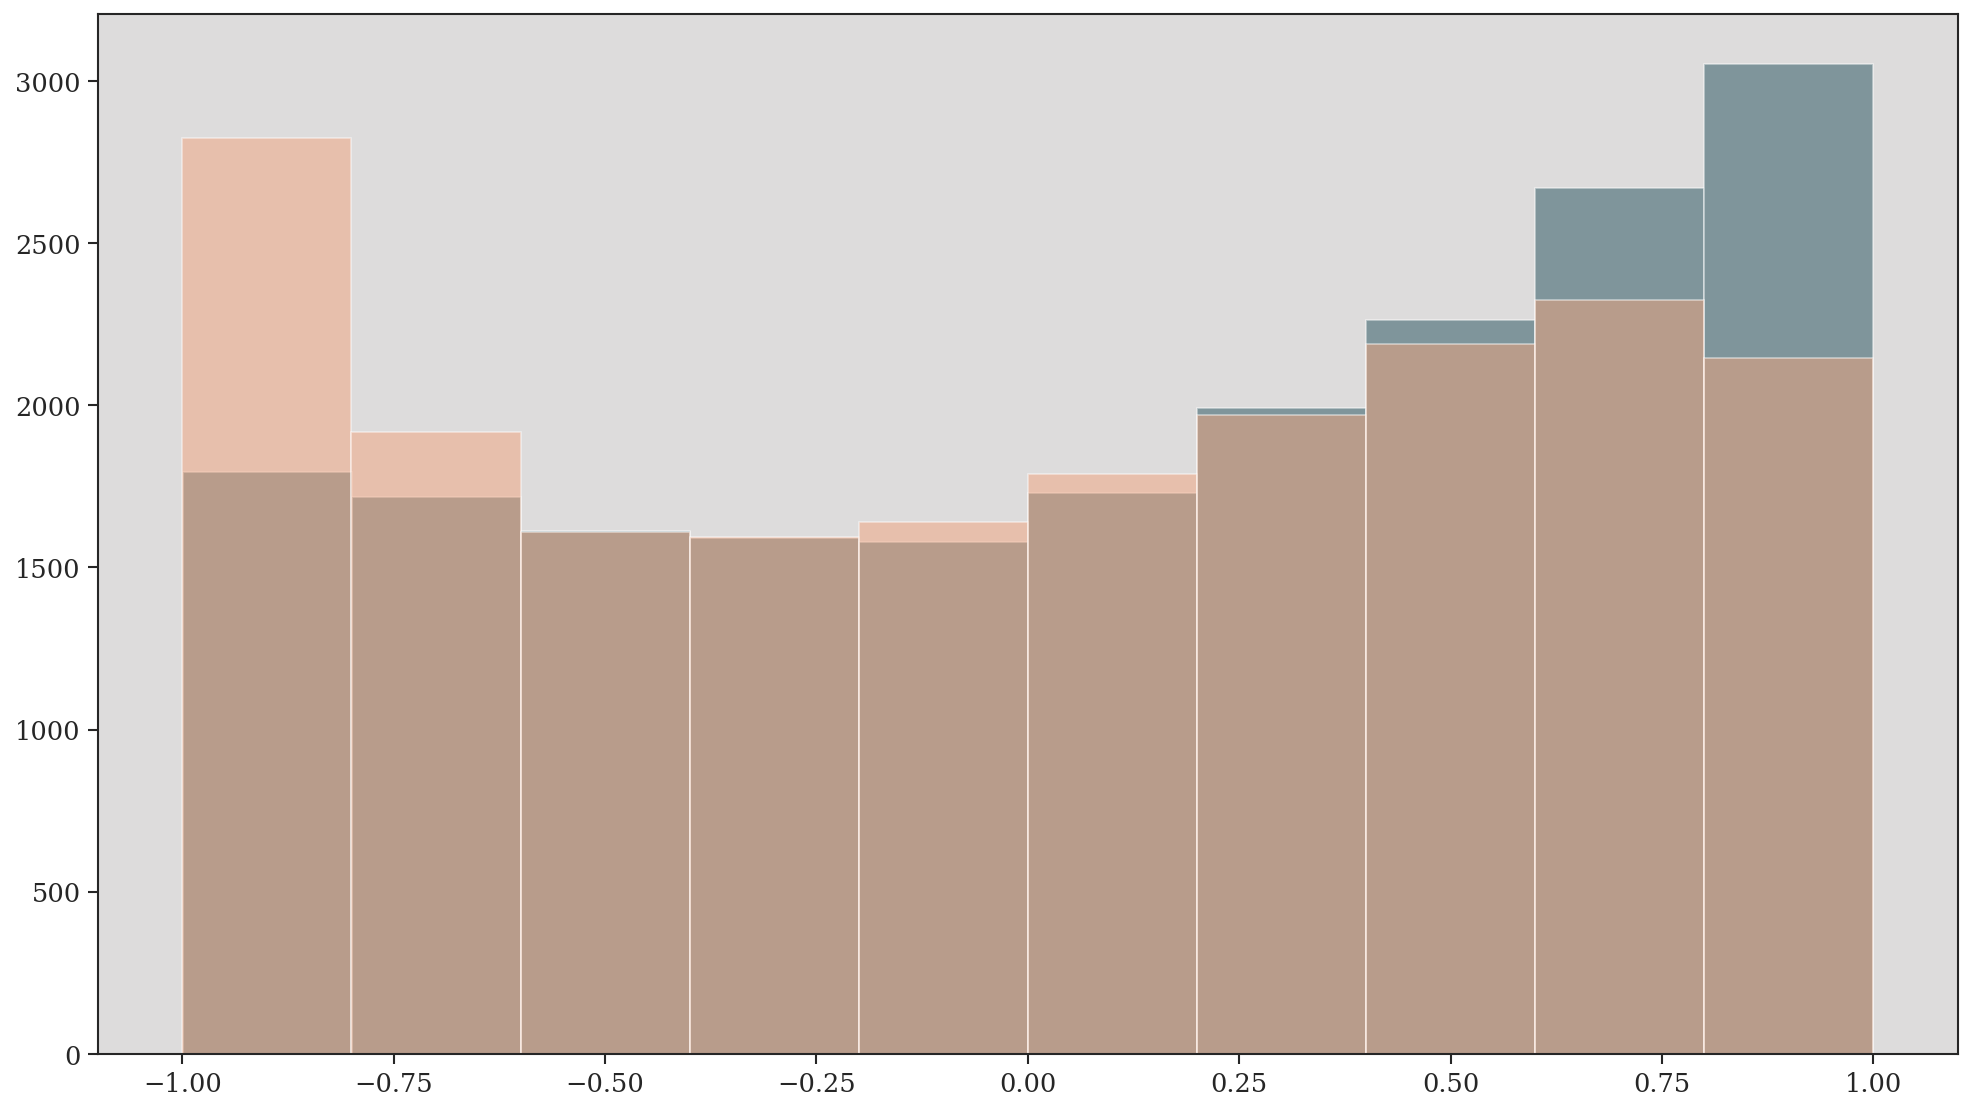

In [2]:
dat = np.genfromtxt('MLE_Variance_data_2.txt')
plt.hist(dat[:,0], alpha = 0.5)
plt.hist(dat[:,1], alpha = 0.5)

______
## unbinned, testing binned

In [6]:
def pdf_f(x,a,b,N):
    return (1 / (2/3 * b *(0.95**3) + 2*0.95) * (1 + a * x + b * x**2))/N

<ErrorbarContainer object of 3 artists>

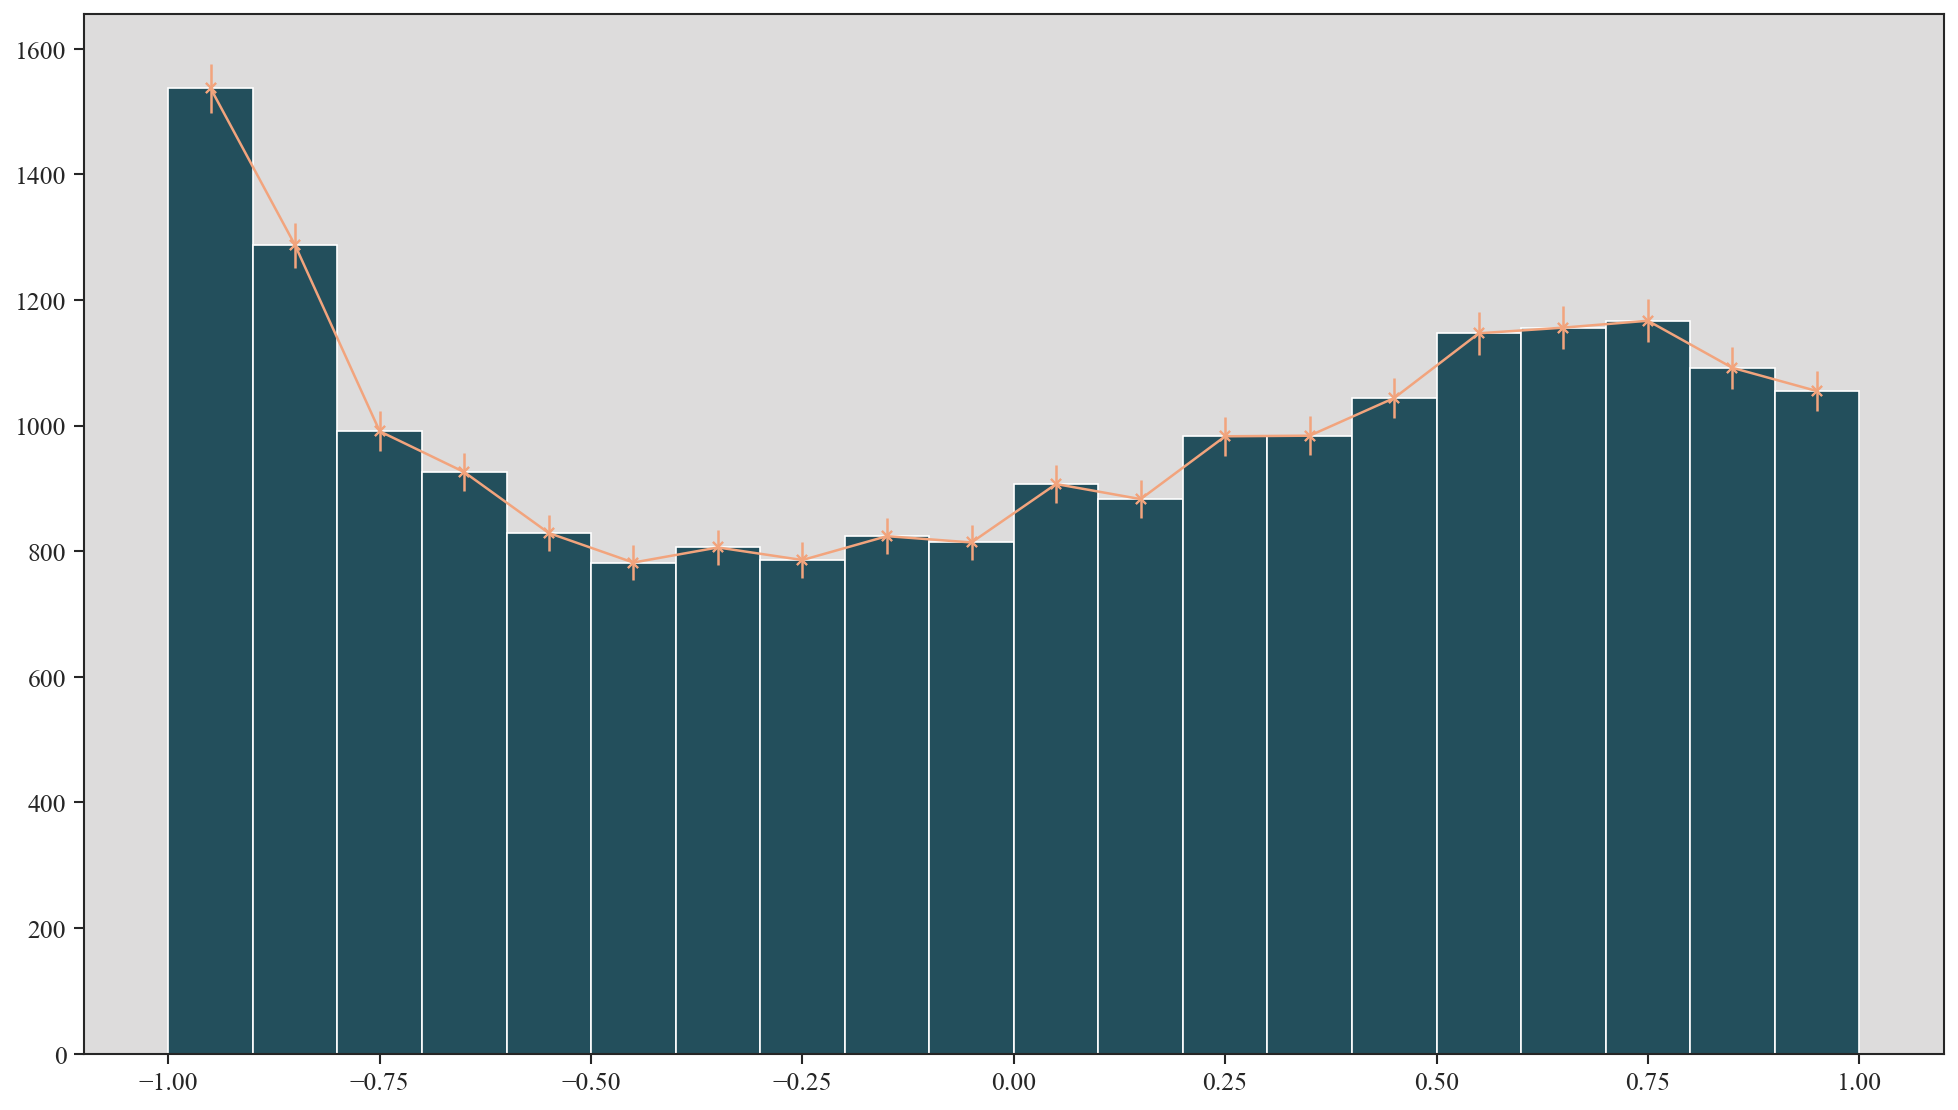

0.4610959579084134


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 21.98 (χ²/ndof = 1.0)      │              Nfcn = 227              │
│ EDM = 6.7e-18 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.408   │   0.016   │            │            │         │         │       │
│ 1 │ b    │   0.559   │   0.034   │            │            │         │         │       │
│ 2 │ N    │  669e-6   │   5e-6    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────┐
│   │         a         b         N │
├───┼───────────────────────────────┤
│ a │  0.000258   0.20e-3  3.074e-9 │
│ b │   0.20e-3   0.00114 17.653e-9 │
│ N │  3.074e-9 17.653e-9  2.27e-11 │
└───┴───────────────────────────────┘

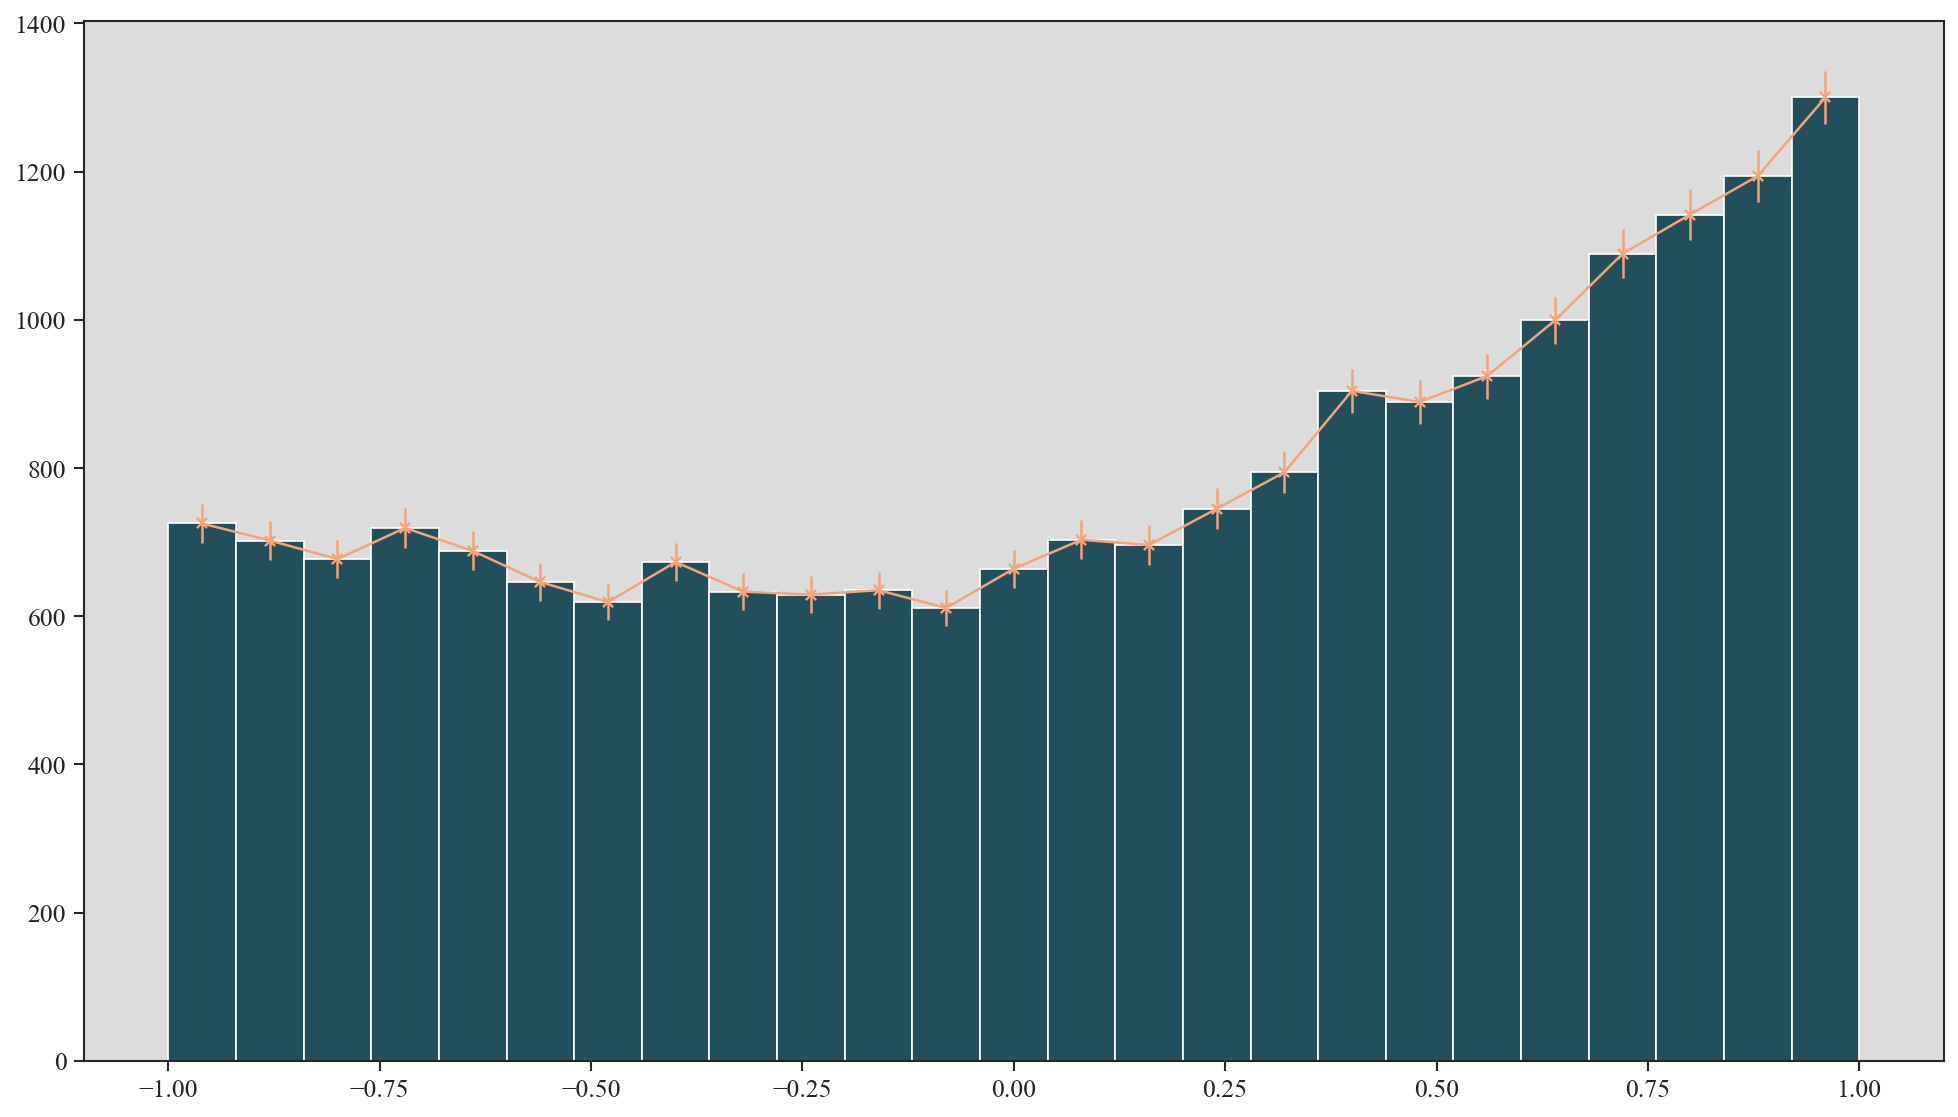

In [22]:
N_bins = 25
bins = np.linspace(-1,1,N_bins+1)
bin_centers = (bins[:-1] + bins[1:]) / 2
counts0 = plt.hist(dat[:,0], bins=bins, density = False)
plt.plot(bin_centers, counts0[0], '-x', color = pallete[1], label = "dat0")
plt.errorbar(bin_centers, counts0[0], yerr = np.sqrt(counts0[0]), fmt = 'x', color = pallete[1])
least_squares = LeastSquares(bin_centers, counts0[0], np.sqrt(counts0[0])  , pdf_f)
m = Minuit(least_squares, a=1.0, b=0.0, N = 250)  # initial guesses
m.migrad()   # minimize
print(scipy.stats.chi2.sf(m.fval,df =len(bin_centers)-m.nfit))
m.migrad()